# Descriptive Analysis

01. Importing libraries

In [2]:
import pandas as pd
import numpy as np
import os

02. Importing Data

Creating a path

In [7]:
path = r'C:\Users\chris\Desktop\Upskilling\CareerFoundry\Data Immersion\Achievement 6_Advanced Analytics and Dashboard Design\11-2025 Coffee Lifestyle Factors Analysis'

Importing data set using the path

In [8]:
df = pd.read_csv(os.path.join(path, '02. Data', 'Original Data', 'synthetic_coffee_health_10000.csv'), index_col = False)

In [10]:
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


03. Checking data

Checking data types in columns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

From this return, I can see that there are no mixed data types in the columns and that all columns have values ie no non-null values, with the exception of the Health_Issues column which does have some empty records. I assume that this is because some individuals might have no health issues and therefore the record for this column is blank. In order to make this clean I shall consider adding a value of 'None' where the health issues column is blank. 

Furthermore the column names are all clear and don't need changing.

The data appears to be anonomysed already so I don't need to remove any unnecessary columns (for example names which would not have been important for my analysis).

04. Descriptive Analysis

In [13]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


This table of descriptive statistics provides us with some useful information to check the numerical variables.

It is has been made clear from the results that the Smoking and Alcohol_Consumption columns must be binary columns and it would appear that less than half of respondants smoke or drink alcohol

Changing the ID variable to string

In [14]:
df['ID'] = df['ID'].astype('str')

Changing the Smoking and Alcohol_Consumption variables to boolean

In [16]:
df[['Smoking', 'Alcohol_Consumption']] = df[['Smoking', 'Alcohol_Consumption']].astype(bool)

Changing the Nan (or missing values) in Health issues to None

In [17]:
df['Health_Issues'] = df['Health_Issues'].fillna('None')
df

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,None,Other,False,False
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,None,Service,False,False
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,False,False
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,False,False
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,False,True
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,False,False
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,None,Student,True,True
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,None,Student,False,False


Rechecking for missing data/blank records

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  object 
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            10000 non-null  object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

Checking for duplicates

In [19]:
df_dups = df[df.duplicated()]

In [20]:
df_dups

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption


There were no duplicate rows found

Importing libraries for visualisation

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

Checking the distribution of numerical variables with histograms

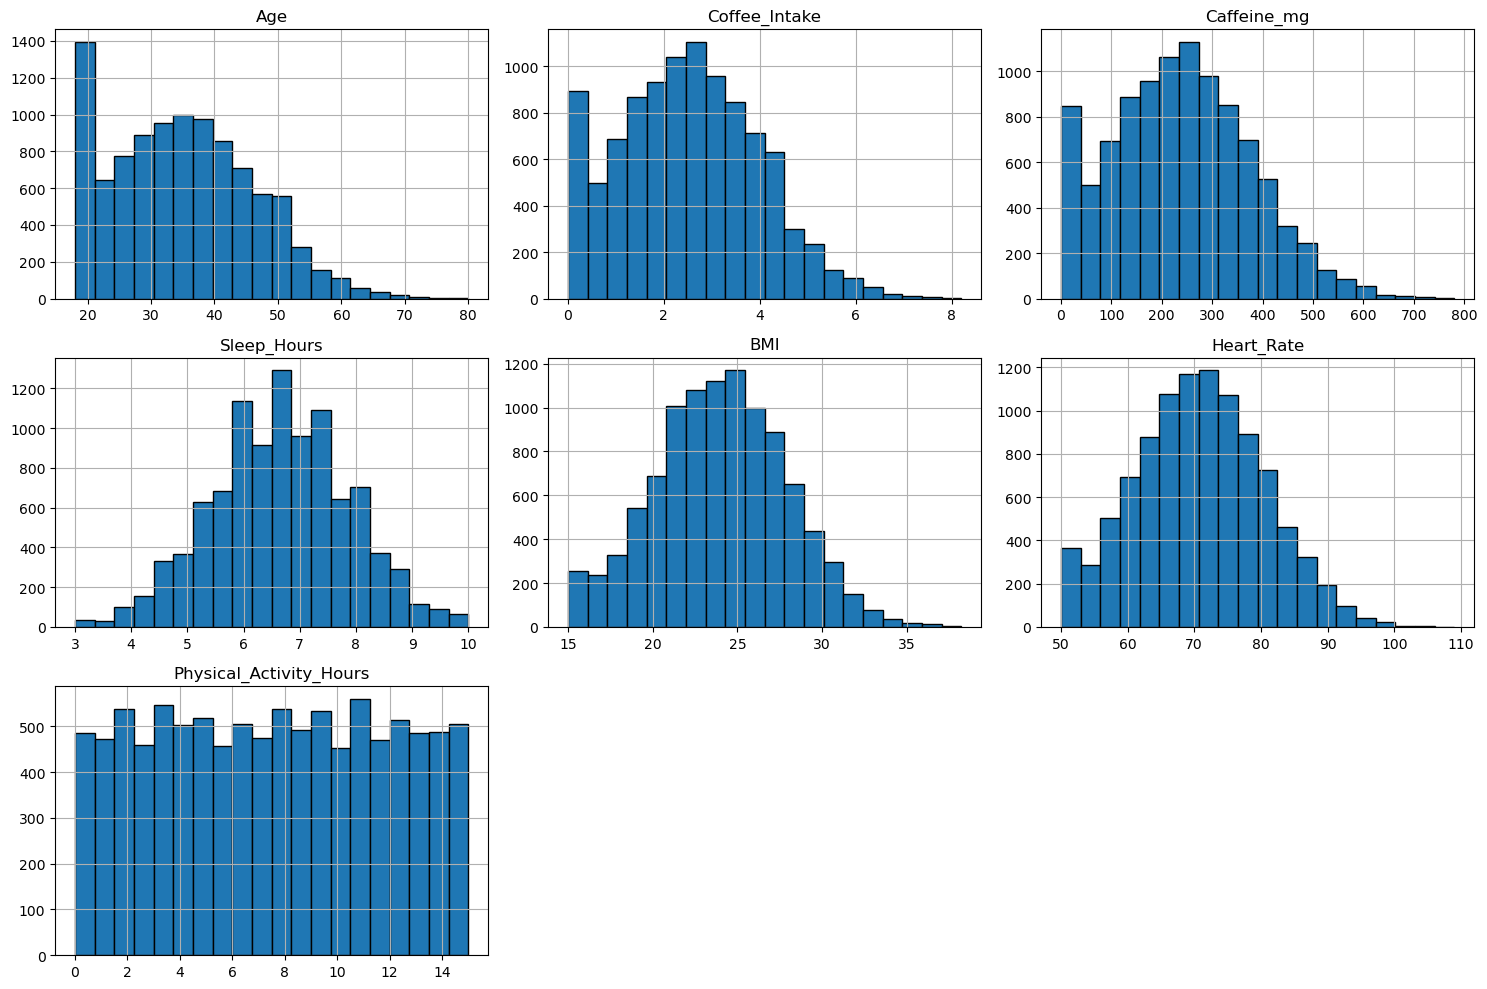

In [25]:
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

Reviewing data distribution for categorial/qaulatative data

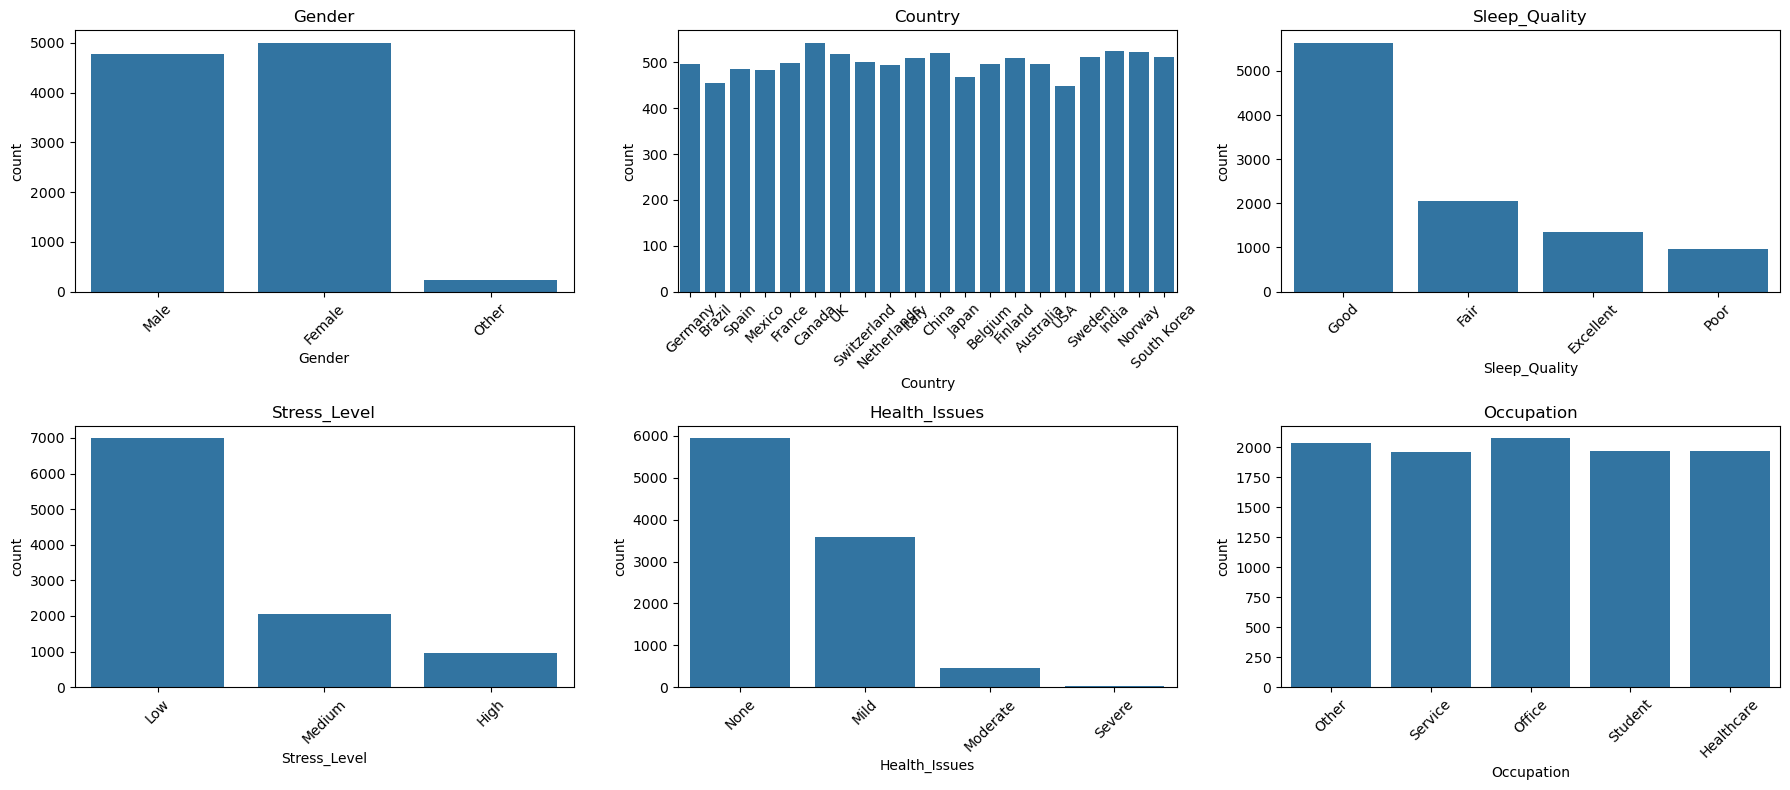

In [31]:
cols = ["Gender", "Country", "Sleep_Quality", "Stress_Level", "Health_Issues", "Occupation"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From these charts a few things standout, namely there is a skew towards people reporting good sleep quality, low stress levels and no health issues. This might mean there are some biases in the dataset. However given that this is synthetic data it might be reflective of general trends in the population.

5. Exporting dataframe

In [32]:
df.to_csv(os.path.join(path, '02. Data','Prepared Data', 'synthetic_coffee_health_clean.csv'))

6. Exporting descriptive histograms

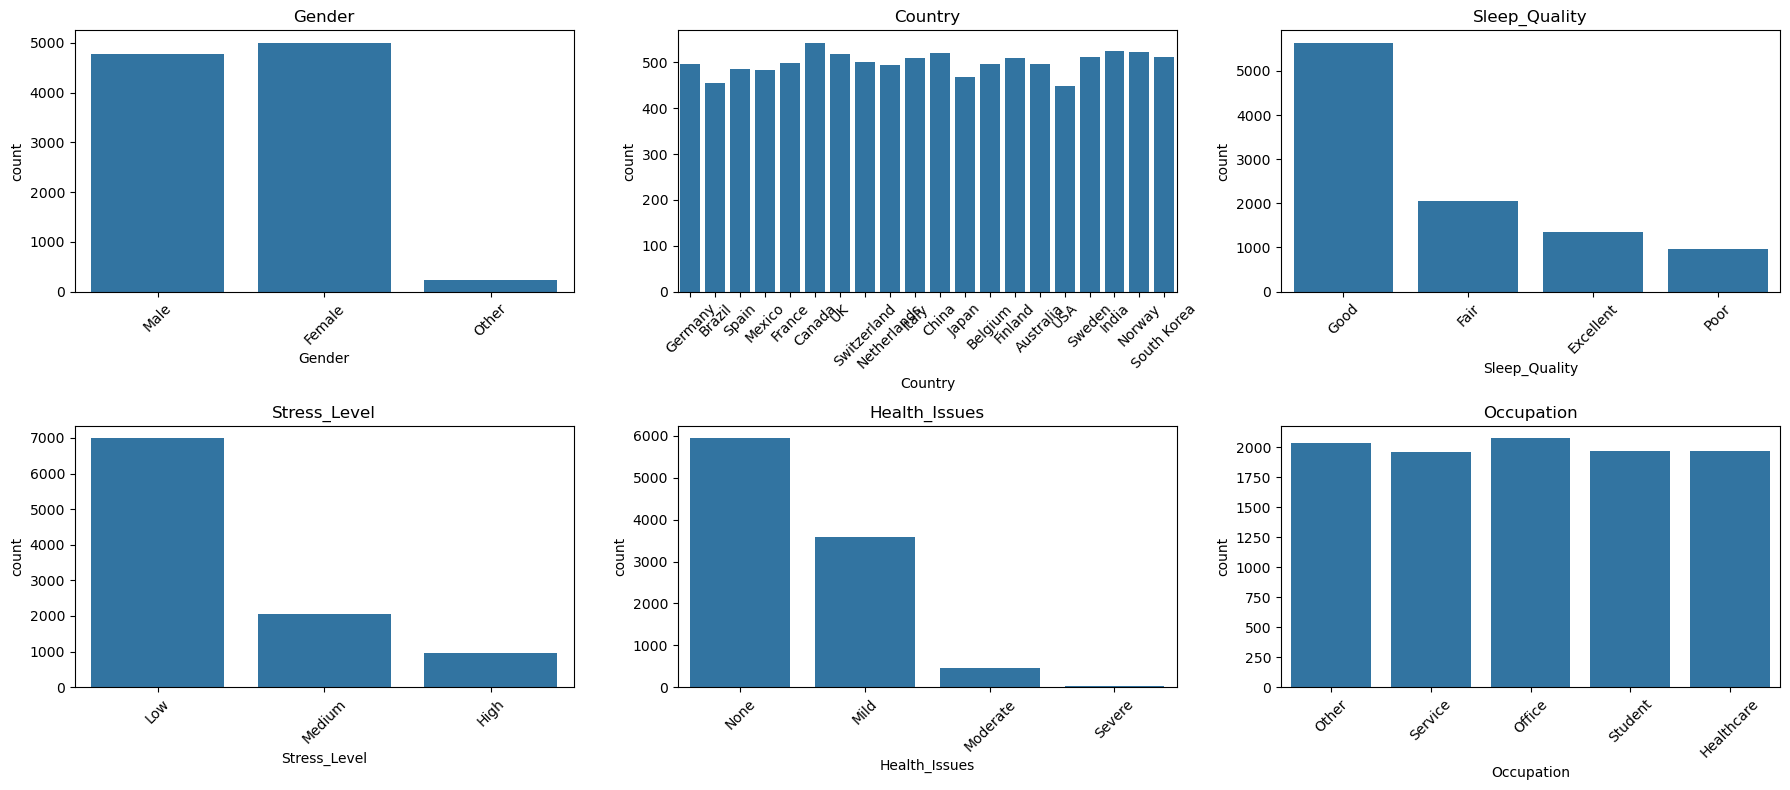

In [34]:
categorial_hist = cols = ["Gender", "Country", "Sleep_Quality", "Stress_Level", "Health_Issues", "Occupation"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()

In [37]:
fig.savefig(os.path.join(path, '04. Analysis', 'Visualisations', 'hist_categorial.png'), bbox_inches='tight')
plt.close(fig)

In [46]:
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.savefig(os.path.join(path, '04. Analysis', 'Visualisations', 'numerical_hist.png'), bbox_inches='tight')
plt.close()